# Directional stiffness — F vs d
This notebook plots the two force channels for vertical pressing: normal force $F_n$ and negative shear force $-F_s$, each across direction angles in the Y-Z plane.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys
from glob import glob

sys.path.insert(0, os.path.join('../../'))
from plot_config import draw_radar, COLORS, FIG_W_SINGLE, FIG_W_DOUBLE, set_font_size
FIG_W = 10   # inches — change freely

FIG_H = 6    # inches — change freely

GRID = False
FONT_SIZE = 18  # pt — change to rescale all text uniformly
set_font_size(FONT_SIZE)

# Shared data box so all normal-force-vs-distance plots match the stiffness sweeps
AX_RECT = [0.15, 0.17, 0.68, 0.76]

OUTPUT_DIR  = os.path.join('outputs', 'directional_stiffness')
COLORS      = plt.rcParams['axes.prop_cycle'].by_key()['color']


def available_angles():
    angles = set()
    for folder in glob(os.path.join(OUTPUT_DIR, 'angle_*')):
        name = os.path.basename(folder)
        try:
            angles.add(int(name.split('_', 1)[1]))
        except ValueError:
            pass
    return sorted(angles)


def load_runs(angle_deg):
    pattern = os.path.join(
        OUTPUT_DIR, f'angle_{angle_deg}',
        f'angle_{angle_deg}_run_*.csv')
    return [pd.read_csv(f) for f in sorted(glob(pattern))]


def interp_disp_phase(dfs, phase, col, n_pts=500):
    """Interpolate one phase (descent/ascent) onto a common displacement grid."""
    disp_force_pairs = []

    for df in dfs:
        if 'Phase' in df.columns:
            phase_df = df[df['Phase'] == phase].copy()
        else:
            phase_df = df.copy()

        if phase_df.empty:
            continue

        phase_df = phase_df.sort_values('UR5_displacement_m')
        grouped = phase_df.groupby('UR5_displacement_m', as_index=False)[col].mean()

        d_vals = grouped['UR5_displacement_m'].to_numpy()
        f_vals = grouped[col].to_numpy()

        if len(d_vals) < 2:
            continue

        disp_force_pairs.append((d_vals, f_vals))

    if not disp_force_pairs:
        return None, None

    d_max = min(0.02, min(d_vals.max() for d_vals, _ in disp_force_pairs))
    d = np.linspace(0, d_max, n_pts)
    vals = np.array([np.interp(d, d_vals, f_vals) for d_vals, f_vals in disp_force_pairs])
    return d, vals


ANGLE_SWEEP = available_angles()
if not ANGLE_SWEEP:
    print('No directional stiffness data found under outputs/directional_stiffness')

data = {angle: load_runs(angle) for angle in ANGLE_SWEEP}
for angle, runs in data.items():
    print(f'angle={angle:2d}°  ->  {len(runs)} run(s)')


angle=-60°  ->  5 run(s)
angle=-30°  ->  5 run(s)
angle= 0°  ->  5 run(s)


## Vertical press

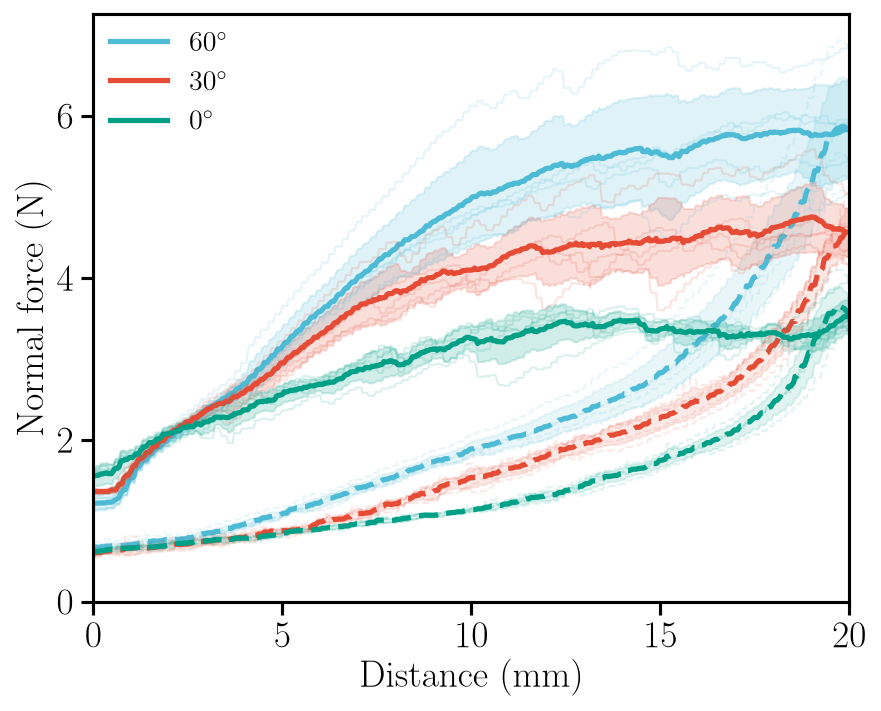

In [2]:
# ---- size / aspect for THIS graph only (shared style applies to the rest) ----
W_IN = 7.41   # figure width  (inches)
H_IN = 5.15   # figure height (inches)

fig = plt.figure(figsize=(W_IN, H_IN))
ax_n = fig.add_axes(AX_RECT)
plotted_any = False

for idx, angle in enumerate(ANGLE_SWEEP):
    runs = data[angle]
    if not runs:
        continue
    color = COLORS[idx % len(COLORS)]
    label = rf'${-angle}^\circ$'

    phase_specs = [
        ('descent', '-', 0.15, 0.18),
        ('ascent',  '--', 0.12, 0.12),
    ]

    for phase, linestyle, raw_alpha, band_alpha in phase_specs:
        d, vals = interp_disp_phase(runs, phase=phase, col='Force_normal_N')
        if vals is None:
            continue

        d_mm = d * 1e3
        mean, std = vals.mean(0), vals.std(0)

        for v in vals:
            ax_n.plot(d_mm, v, color=color, alpha=raw_alpha, linewidth=1, linestyle=linestyle)
        ax_n.plot(d_mm, mean, color=color, linewidth=2.5, linestyle=linestyle,
                  label=label if phase == 'descent' else None)
        ax_n.fill_between(d_mm, mean - std, mean + std, color=color, alpha=band_alpha)
        plotted_any = True

ax_n.set_xlabel('Distance (mm)')
ax_n.set_ylabel('Normal force (N)')
if plotted_any:
    ax_n.legend(loc='upper left')
else:
    print('No vertical data available to plot.')
ax_n.set_xlim(0, 20)
ax_n.set_ylim(bottom=0)

os.makedirs(OUTPUT_DIR, exist_ok=True)
fig.savefig(os.path.join(OUTPUT_DIR, 'vertical_F_vs_d.pdf'), bbox_inches=fig.bbox_inches)
plt.show()


## Fingertip stiffness from Jacobians (pseudoinverse mapping)
For this experiment we use the active model:
- Joint virtual stiffness is disabled: $K_{joint}=0$.
- Motor efficiency is fixed to identity: $\eta = I$.
- Output projection is fixed to 0° direction: $P = n_0 n_0^T$, with $n_0=[0,0,1]^T$.
- The cart spring direction $n$ still follows each angle condition.

So the implemented equations are:

$$
K_{motor} = J_{tip}^T K_{cart} J_{tip}, \quad K_{cart}=k_{cart}\,n n^T
$$

$$
K_x = (P J_{tip})^{+T} K_{motor} (P J_{tip})^{+}, \quad P=n_0 n_0^T
$$

We report stiffness along 0° direction:

$$
k_{0^\circ} = n_0^T K_x n_0
$$

Below we plot $k_{0^\circ}$ versus displacement $d$ and summarize the mid-range mean/std for each angle dataset.

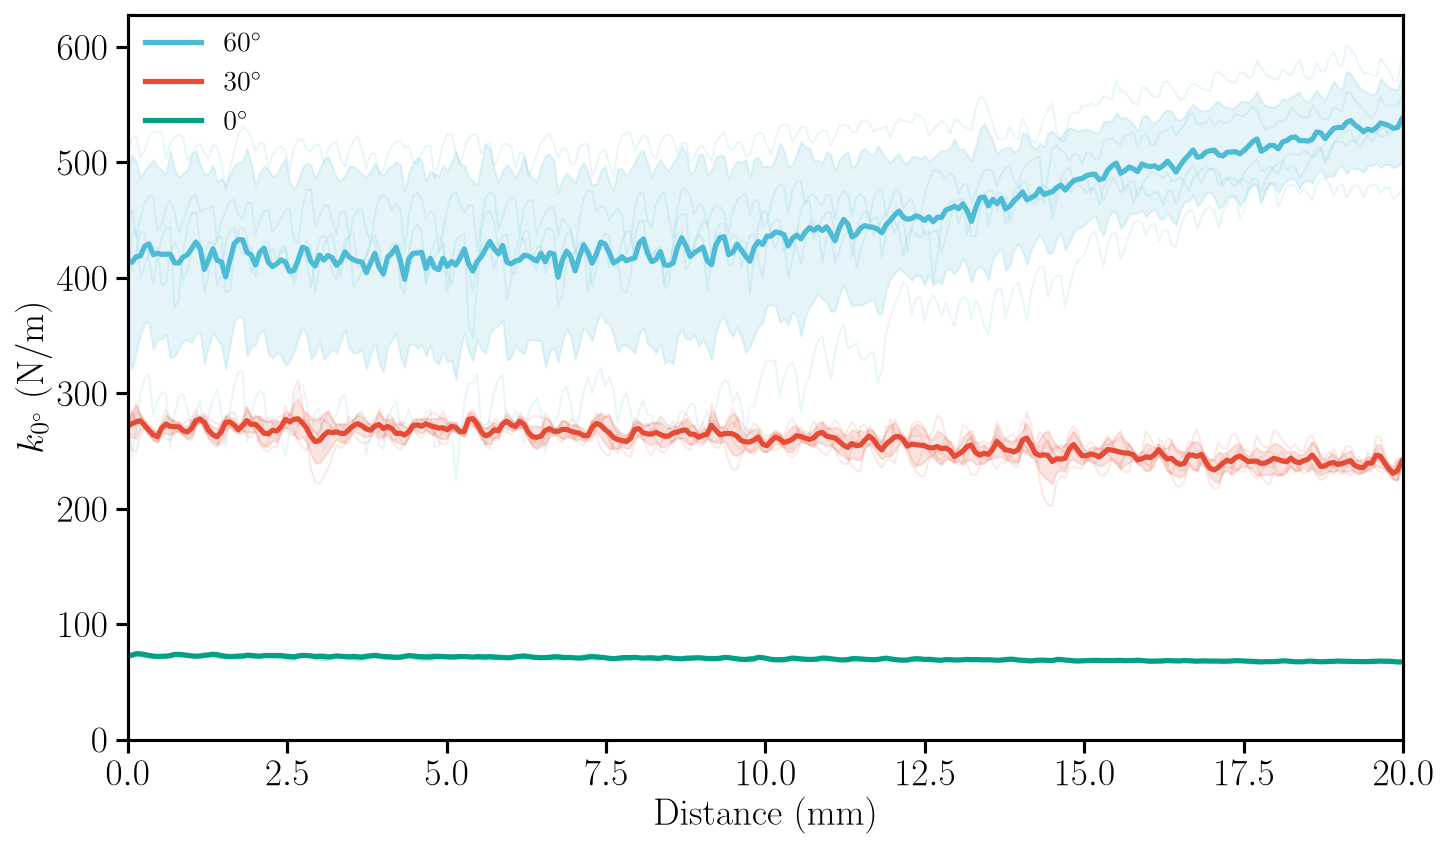

,angle_deg,k_0deg_mean_mid_Npm,k_0deg_std_mid_Npm
0,-60,432.350611,20.996997
1,-30,262.475748,8.170850
2,0,70.583859,1.254869


In [3]:
from KinematicsFinger.JacobiansFinger import q2DIP
from ModelIDFinger.finger_params import c, eta

J_tip_fun = q2DIP()
r_tip = np.array([0.0, c, 0.0])

# Match experiment settings in PassiveCompliance/directional_stiffness.py
K_CART_EXPERIMENT = 100.0  # (N/m)
N0 = np.array([0.0, 0.0, 1.0]).reshape(3, 1)  # fixed 0° direction
P0 = N0 @ N0.T


def n_from_angle(angle_deg):
    ang = np.radians(angle_deg)
    n = np.array([0.0, np.sin(ang), np.cos(ang)], dtype=float)
    return n / np.linalg.norm(n)


def fingertip_stiffness_from_q(q_deg, angle_deg, k_cart=K_CART_EXPERIMENT):
    q_rad = np.radians(q_deg)
    J_tip = np.asarray(J_tip_fun(q_rad[0], q_rad[1], *r_tip), dtype=float)  # (3x2)

    n = n_from_angle(angle_deg).reshape(3, 1)

    K_cart = k_cart * (n @ n.T)
    K_motor = np.diag(eta) @ J_tip.T @ K_cart @ J_tip

    # User correction: projection matrix is fixed at 0° direction
    J_proj = P0 @ J_tip
    J_proj_pinv = np.linalg.pinv(J_proj)

    K_tip = J_proj_pinv.T @ K_motor @ J_proj_pinv
    k_0deg = float((N0.T @ K_tip @ N0).squeeze())
    return K_tip, k_0deg


def run_k0_curve(df_run, angle_deg, phase='descent'):
    if 'Phase' in df_run.columns:
        df_use = df_run[df_run['Phase'] == phase].copy()
    else:
        df_use = df_run.copy()
    if df_use.empty:
        return None, None

    df_use = df_use.sort_values('UR5_displacement_m')

    d_vals = []
    k_vals = []
    for _, row in df_use.iterrows():
        q_deg = np.array([row['Motor1_pos_deg'], row['Motor2_pos_deg']], dtype=float)
        _, k_0deg = fingertip_stiffness_from_q(q_deg, angle_deg)
        d_vals.append(float(row['UR5_displacement_m']))
        k_vals.append(k_0deg)

    d_vals = np.asarray(d_vals)
    k_vals = np.asarray(k_vals)

    # Average repeated displacement samples
    d_unique = np.unique(d_vals)
    k_unique = np.array([k_vals[d_vals == d0].mean() for d0 in d_unique])
    return d_unique, k_unique


fig, ax_k = plt.subplots(1, 1, figsize=(FIG_W, FIG_H))
plotted_any = False
summary_rows = []

for idx, angle in enumerate(ANGLE_SWEEP):
    runs = data[angle]
    if not runs:
        continue

    color = COLORS[idx % len(COLORS)]
    label = rf'${-angle}^\circ$'

    curves = []
    for df_run in runs:
        d_run, k_run = run_k0_curve(df_run, angle, phase='descent')
        if d_run is None or len(d_run) < 2:
            continue
        curves.append((d_run, k_run))

    if not curves:
        continue

    d_max = min(0.02, min(d.max() for d, _ in curves))
    d_grid = np.linspace(0.0, d_max, 300)
    k_interp = np.array([np.interp(d_grid, d, k) for d, k in curves])

    k_mean = k_interp.mean(axis=0)
    k_std = k_interp.std(axis=0)

    for k in k_interp:
        ax_k.plot(d_grid * 1e3, k, color=color, alpha=0.12, linewidth=1.0)
    ax_k.plot(d_grid * 1e3, k_mean, color=color, linewidth=2.5, label=label)
    ax_k.fill_between(d_grid * 1e3, k_mean - k_std, k_mean + k_std, color=color, alpha=0.15)

    mask_mid = (d_grid >= 0.002) & (d_grid <= 0.015)
    summary_rows.append({
        'angle_deg': angle,
        'k_0deg_mean_mid_Npm': float(k_mean[mask_mid].mean()) if mask_mid.any() else float(k_mean.mean()),
        'k_0deg_std_mid_Npm': float(k_mean[mask_mid].std()) if mask_mid.any() else float(k_mean.std()),
    })
    plotted_any = True

ax_k.set_xlabel('Distance (mm)')
ax_k.set_ylabel(r'$k_{0^\circ}$ (N/m)')
if plotted_any:
    ax_k.legend(loc='upper left')
else:
    print('No data available to compute fingertip stiffness.')
ax_k.set_xlim(0, 20)
ax_k.set_ylim(bottom=0)

plt.tight_layout()
os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.savefig(os.path.join(OUTPUT_DIR, 'vertical_tip_stiffness_k0deg_vs_d.pdf'))
plt.show()

if summary_rows:
    summary_df = pd.DataFrame(summary_rows).sort_values('angle_deg')
    display(summary_df)
else:
    print('No stiffness summary available.')